## **Figure-S3**

In [1]:
import sys
import os
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
numpy Version 2.2.2
matplotlib version 3.10.0
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
osw = []
pth = "../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/"
for i in os.listdir(pth):
    osw.append(getPrecursorDf_oswpq(pth + i, suffix='', cutoff=0.01, columns=['PRECURSOR_MZ']))
osw = pd.concat(osw).drop_duplicates()
# compute how far it is away from the edge
distance = osw['PRECURSOR_MZ'] % 5
osw['EdgeEffect'] = np.minimum(distance, 5-distance)


../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA400_SP2um_90min_250ngK562_100nL_Slot1-5_1_1316_6-27-2021.oswpq
../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA520_SP2um_90min_250ngK562_100nL_Slot1-5_1_1318_6-27-2021.oswpq
../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA880_SP2um_90min_250ngK562_100nL_Slot1-5_1_1324_6-27-2021.oswpq
../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA460_SP2um_90min_250ngK562_100nL_Slot1-5_1_1317_6-27-2021.oswpq
../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA580_SP2um_90min_250ngK562_100nL_Slot1-5_1_1319_6-27-2021.oswpq
../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA940_SP2um_90min_250ngK562_100nL_Slot1-5_1_1325_6-27-2021.oswpq
../../results/K562-Refine-Exp-Lib-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA1060_SP2um_90min_250ngK562_100nL_Slot1-5_1_1327_

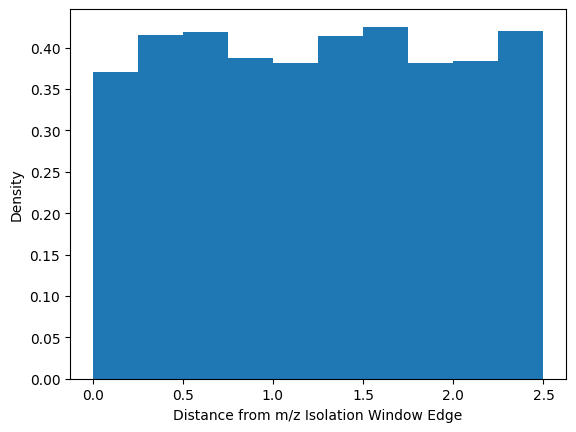

In [4]:
fig, ax = plt.subplots(1,1)
plt.hist(osw['EdgeEffect'], bins=10, density=True)
plt.xlabel("Distance from m/z Isolation Window Edge")
plt.ylabel("Density")
fig.savefig("Figure-S3.png", dpi=300, bbox_inches='tight')